In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [2]:
# Cargar datasets DEV y TEST
df_dev = pd.read_csv('../data/processed/dev_dataset.csv')
df_test_full = pd.read_csv('../data/processed/test_dataset.csv')

# Para feature engineering, trabajaremos con DEV completo primero
df = df_dev.copy()

with open('../data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"DEV dataset shape: {df.shape}")
print(f"TEST dataset shape: {df_test_full.shape}")
print(f"Features originales: {len(feature_cols)}")

DEV dataset shape: (82404, 38)
TEST dataset shape: (22203, 38)
Features originales: 31


## 2. Feature Engineering

Vamos a crear nuevas features basadas en:
- Estadísticas agregadas de temperatura y precipitación (media, std, min, max por año)
- Features estacionales (verano, otoño, invierno, primavera)
- Interacciones entre temperatura y precipitación
- Ratios y transformaciones de features de suelo

In [3]:
def create_engineered_features(df):
    """
    Crea nuevas features mediante feature engineering.
    """
    df_eng = df.copy()
    
    temp_cols = [f'temperatura_mes_{i}' for i in range(1, 13)]
    precip_cols = [f'precipitacion_mes_{i}' for i in range(1, 13)]
    
    print("Creando features de estadísticas anuales...")
    df_eng['temp_media_anual'] = df[temp_cols].mean(axis=1)
    df_eng['temp_std_anual'] = df[temp_cols].std(axis=1)
    df_eng['temp_min_anual'] = df[temp_cols].min(axis=1)
    df_eng['temp_max_anual'] = df[temp_cols].max(axis=1)
    df_eng['temp_rango_anual'] = df_eng['temp_max_anual'] - df_eng['temp_min_anual']
    
    df_eng['precip_total_anual'] = df[precip_cols].sum(axis=1)
    df_eng['precip_media_anual'] = df[precip_cols].mean(axis=1)
    df_eng['precip_std_anual'] = df[precip_cols].std(axis=1)
    df_eng['precip_min_anual'] = df[precip_cols].min(axis=1)
    df_eng['precip_max_anual'] = df[precip_cols].max(axis=1)
    
    print("Creando features estacionales (hemisferio sur)...")
    verano_meses = [12, 1, 2]
    otoño_meses = [3, 4, 5]
    invierno_meses = [6, 7, 8]
    primavera_meses = [9, 10, 11]
    
    df_eng['temp_verano'] = df[[f'temperatura_mes_{m}' for m in verano_meses]].mean(axis=1)
    df_eng['temp_otoño'] = df[[f'temperatura_mes_{m}' for m in otoño_meses]].mean(axis=1)
    df_eng['temp_invierno'] = df[[f'temperatura_mes_{m}' for m in invierno_meses]].mean(axis=1)
    df_eng['temp_primavera'] = df[[f'temperatura_mes_{m}' for m in primavera_meses]].mean(axis=1)
    
    df_eng['precip_verano'] = df[[f'precipitacion_mes_{m}' for m in verano_meses]].sum(axis=1)
    df_eng['precip_otoño'] = df[[f'precipitacion_mes_{m}' for m in otoño_meses]].sum(axis=1)
    df_eng['precip_invierno'] = df[[f'precipitacion_mes_{m}' for m in invierno_meses]].sum(axis=1)
    df_eng['precip_primavera'] = df[[f'precipitacion_mes_{m}' for m in primavera_meses]].sum(axis=1)
    
    print("Creando features de interacción...")
    df_eng['temp_precip_ratio'] = df_eng['temp_media_anual'] / (df_eng['precip_media_anual'] + 1)
    df_eng['temp_x_precip'] = df_eng['temp_media_anual'] * df_eng['precip_media_anual']
    
    print("Creando features de variabilidad climática...")
    df_eng['coef_var_temp'] = df_eng['temp_std_anual'] / (df_eng['temp_media_anual'] + 1)
    df_eng['coef_var_precip'] = df_eng['precip_std_anual'] / (df_eng['precip_media_anual'] + 1)
    
    print("Creando features de suelo...")
    df_eng['suelo_calidad_score'] = (df_eng['suelo_ind_prod'] * df_eng['suelo_porc_sue1'] * 
                                      df_eng['suelo_profund_s1']) / 10000
    
    print("Creando features de producción...")
    df_eng['produccion_por_hectarea'] = df_eng['produccion_total'] / (df_eng['sup_sembrada_total'] + 1)
    
    print("Creando features de crecimiento por estación...")
    df_eng['temp_diff_verano_invierno'] = df_eng['temp_verano'] - df_eng['temp_invierno']
    df_eng['precip_diff_verano_invierno'] = df_eng['precip_verano'] - df_eng['precip_invierno']
    
    print(f"\nFeatures creadas. Shape final: {df_eng.shape}")
    return df_eng

In [4]:
# Aplicar feature engineering a DEV
df_dev_engineered = create_engineered_features(df)
print(f"\nDEV con feature engineering - Shape: {df_dev_engineered.shape}")

# Aplicar feature engineering a TEST
df_test_engineered = create_engineered_features(df_test_full)
print(f"TEST con feature engineering - Shape: {df_test_engineered.shape}")

print(f"\nNuevas columnas creadas: {df_dev_engineered.shape[1] - df.shape[1]}")

Creando features de estadísticas anuales...
Creando features estacionales (hemisferio sur)...
Creando features de interacción...
Creando features de variabilidad climática...
Creando features de suelo...
Creando features de producción...
Creando features de crecimiento por estación...

Features creadas. Shape final: (82404, 64)

DEV con feature engineering - Shape: (82404, 64)
Creando features de estadísticas anuales...
Creando features estacionales (hemisferio sur)...
Creando features de interacción...
Creando features de variabilidad climática...
Creando features de suelo...
Creando features de producción...
Creando features de crecimiento por estación...

Features creadas. Shape final: (22203, 64)
TEST con feature engineering - Shape: (22203, 64)

Nuevas columnas creadas: 26


In [5]:
new_features = [col for col in df_dev_engineered.columns if col not in df.columns]
print(f"\nNuevas features creadas ({len(new_features)}):")
for i, feat in enumerate(new_features, 1):
    print(f"{i}. {feat}")


Nuevas features creadas (26):
1. temp_media_anual
2. temp_std_anual
3. temp_min_anual
4. temp_max_anual
5. temp_rango_anual
6. precip_total_anual
7. precip_media_anual
8. precip_std_anual
9. precip_min_anual
10. precip_max_anual
11. temp_verano
12. temp_otoño
13. temp_invierno
14. temp_primavera
15. precip_verano
16. precip_otoño
17. precip_invierno
18. precip_primavera
19. temp_precip_ratio
20. temp_x_precip
21. coef_var_temp
22. coef_var_precip
23. suelo_calidad_score
24. produccion_por_hectarea
25. temp_diff_verano_invierno
26. precip_diff_verano_invierno


In [6]:
# --- Comprobación automática de posibles features que filtran el target (data leakage) ---
# Umbral de correlación absoluta con el target para considerar una feature como 'filtrante'
leak_corr_threshold = 0.90

# Calculamos correlación absoluta con 'rendimiento' solo para las engineered features
try:
    corr = df_dev_engineered[new_features + ['rendimiento']].corr()['rendimiento'].abs()
except Exception as e:
    print('Error calculando correlaciones:', e)
    corr = None

dropped_engineered_features = []
if corr is not None:
    # Excluir la propia columna 'rendimiento' si aparece
    corr = corr.drop(labels=['rendimiento'], errors='ignore')
    # Seleccionar engineered features con correlación >= umbral
    leak_feats = corr[corr >= leak_corr_threshold].index.tolist()
    # Filtrar solo entre las engineered (por seguridad)
    leak_feats = [f for f in leak_feats if f in new_features]
    if len(leak_feats) > 0:
        print(f'Features ENGINEERED detectadas con correlación >= {leak_corr_threshold}:')
        for f in leak_feats:
            print(' -', f, f'(corr={corr[f]:.4f})')
        # Eliminar estas columnas de los dataframes (DEV y TEST) y actualizar new_features
        df_dev_engineered.drop(columns=leak_feats, inplace=True, errors='ignore')
        df_test_engineered.drop(columns=leak_feats, inplace=True, errors='ignore')
        new_features = [f for f in new_features if f not in leak_feats]
        dropped_engineered_features = leak_feats
    else:
        print(f'No se detectaron engineered features con correlación >= {leak_corr_threshold}.')
else:
    print('No se pudo calcular correlaciones; se omite la detección automática.')

print(f"Features eliminadas: {dropped_engineered_features}" if len(dropped_engineered_features)>0 else "No se eliminaron features.")
print('Features eliminadas:', dropped_engineered_features)

Features ENGINEERED detectadas con correlación >= 0.9:
 - produccion_por_hectarea (corr=0.9825)
Features eliminadas: ['produccion_por_hectarea']
Features eliminadas: ['produccion_por_hectarea']


## 3. Correlación de Nuevas Features con Rendimiento

Correlación de nuevas features con rendimiento (ordenado por magnitud):
precip_verano                  0.150225
temp_x_precip                  0.139574
precip_total_anual             0.128699
precip_media_anual             0.128699
precip_std_anual               0.126474
precip_max_anual               0.121863
precip_otoño                   0.114017
precip_diff_verano_invierno    0.103952
temp_primavera                 0.098572
temp_min_anual                 0.098430
temp_media_anual               0.095802
temp_invierno                  0.088410
temp_otoño                     0.085901
temp_std_anual                 0.078381
temp_rango_anual               0.076497
precip_primavera               0.075925
precip_min_anual               0.062182
temp_diff_verano_invierno      0.050410
temp_max_anual                 0.037376
temp_verano                    0.035929
precip_invierno                0.035247
coef_var_precip                0.033685
temp_precip_ratio              0.029741
coef_var

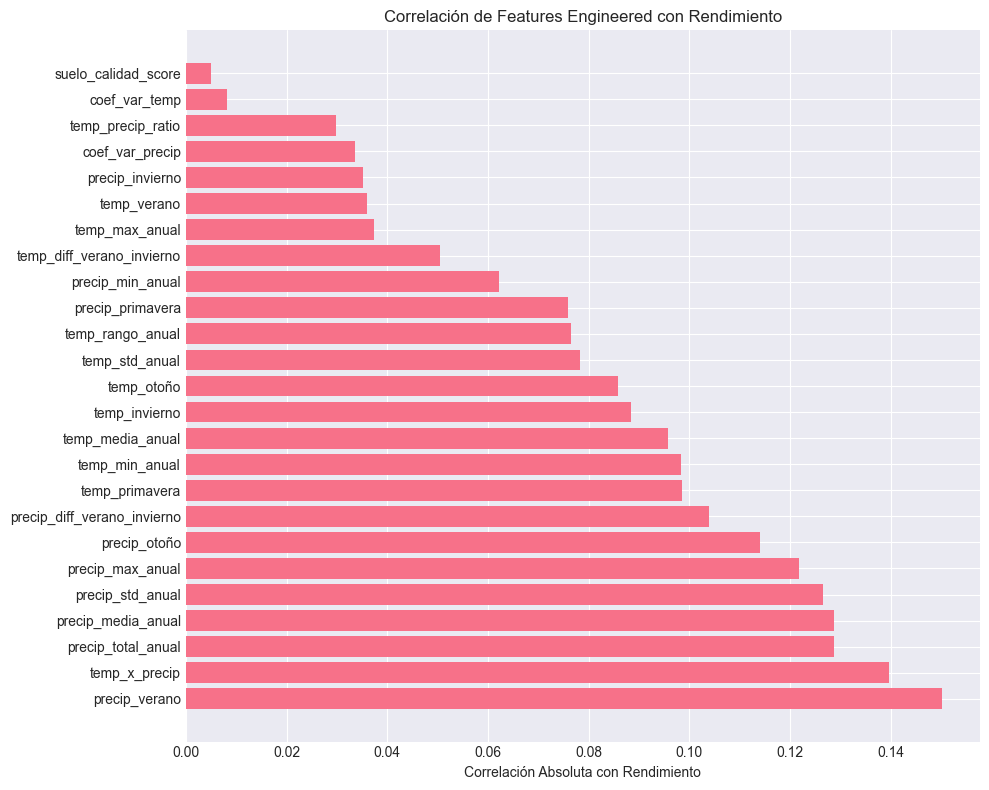

In [7]:
correlation_with_target = df_dev_engineered[new_features + ['rendimiento']].corr()['rendimiento'].drop('rendimiento')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

print("Correlación de nuevas features con rendimiento (ordenado por magnitud):")
print(correlation_with_target)

plt.figure(figsize=(10, 8))
plt.barh(range(len(correlation_with_target)), correlation_with_target.values)
plt.yticks(range(len(correlation_with_target)), correlation_with_target.index)
plt.xlabel('Correlación Absoluta con Rendimiento')
plt.title('Correlación de Features Engineered con Rendimiento')
plt.tight_layout()
plt.savefig('../figures/feature_engineering_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. División TRAIN/VAL/TEST con Features Engineered

**División en 3 conjuntos:**
- TRAIN: 1970-2004 (80% de DEV) - entrenar modelos
- VAL: 2005-2013 (20% de DEV) - validar hiperparámetros  
- TEST: 2014-2025 - evaluación final

In [8]:
feature_cols_eng = feature_cols + new_features

print(f"Total de features (originales + engineered): {len(feature_cols_eng)}")
print(f"Features originales: {len(feature_cols)}")
print(f"Features engineered: {len(new_features)}")

Total de features (originales + engineered): 56
Features originales: 31
Features engineered: 25


In [9]:
# Dividir DEV en TRAIN/VAL (80/20 cronológico)
df_dev_sorted = df_dev_engineered.sort_values('año').reset_index(drop=True)

años_dev = sorted(df_dev_sorted['año'].unique())
n_años_dev = len(años_dev)
split_año_idx_dev = int(n_años_dev * 0.8)
año_split_train_val = años_dev[split_año_idx_dev]

print(f"Total de años en DEV: {n_años_dev}")
print(f"Año de split TRAIN/VAL: {año_split_train_val}")
print(f"TRAIN: años {años_dev[0]} a {años_dev[split_año_idx_dev-1]}")
print(f"VAL: años {años_dev[split_año_idx_dev]} a {años_dev[-1]}")

# Crear máscaras
train_mask = df_dev_sorted['año'] < año_split_train_val
val_mask = df_dev_sorted['año'] >= año_split_train_val

df_train = df_dev_sorted[train_mask].copy()
df_val = df_dev_sorted[val_mask].copy()
df_test = df_test_engineered.sort_values('año').reset_index(drop=True)

# Extraer features engineered
X_train_eng = df_train[feature_cols_eng].values
y_train_eng = df_train['rendimiento'].values
X_val_eng = df_val[feature_cols_eng].values
y_val_eng = df_val['rendimiento'].values
X_test_eng = df_test[feature_cols_eng].values
y_test_eng = df_test['rendimiento'].values

print(f"\nTamaño TRAIN: {X_train_eng.shape} ({len(df_train)/len(df_dev_sorted)*100:.1f}% de DEV)")
print(f"Tamaño VAL: {X_val_eng.shape} ({len(df_val)/len(df_dev_sorted)*100:.1f}% de DEV)")
print(f"Tamaño TEST: {X_test_eng.shape}")
print(f"\nDistribución temporal:")
print(f"  TRAIN: {df_train['año'].min()}-{df_train['año'].max()}")
print(f"  VAL: {df_val['año'].min()}-{df_val['año'].max()}")
print(f"  TEST: {df_test['año'].min()}-{df_test['año'].max()}")

Total de años en DEV: 44
Año de split TRAIN/VAL: 2005
TRAIN: años 1970 a 2004
VAL: años 2005 a 2013

Tamaño TRAIN: (67229, 56) (81.6% de DEV)
Tamaño VAL: (15175, 56) (18.4% de DEV)
Tamaño TEST: (22203, 56)

Distribución temporal:
  TRAIN: 1970-2004
  VAL: 2005-2013
  TEST: 2014-2025


In [10]:
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_val_eng_scaled = scaler_eng.transform(X_val_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

print("Datos escalados (scaler ajustado SOLO en TRAIN).")

Datos escalados (scaler ajustado SOLO en TRAIN).


## 5. PCA sobre Features Engineered

In [11]:
pca_eng_full = PCA()
pca_eng_full.fit(X_train_eng_scaled)

varianza_acumulada = np.cumsum(pca_eng_full.explained_variance_ratio_)
n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"Componentes necesarios para 95% de varianza: {n_components_95}")

pca_eng = PCA(n_components=n_components_95)
X_train_eng_pca = pca_eng.fit_transform(X_train_eng_scaled)
X_val_eng_pca = pca_eng.transform(X_val_eng_scaled)
X_test_eng_pca = pca_eng.transform(X_test_eng_scaled)

print(f"X_train_eng_pca shape: {X_train_eng_pca.shape}")
print(f"X_val_eng_pca shape: {X_val_eng_pca.shape}")
print(f"X_test_eng_pca shape: {X_test_eng_pca.shape}")
print("\nPCA ajustado SOLO en TRAIN, aplicado a VAL y TEST.")

Componentes necesarios para 95% de varianza: 21
X_train_eng_pca shape: (67229, 21)
X_val_eng_pca shape: (15175, 21)
X_test_eng_pca shape: (22203, 21)

PCA ajustado SOLO en TRAIN, aplicado a VAL y TEST.


## 6. Funciones de Evaluación

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

## 7. Entrenamiento en TRAIN+VAL, Evaluación en TEST

Entrenaremos los modelos en TRAIN+VAL y evaluaremos en TEST (una sola vez).

In [13]:
# Combinar TRAIN y VAL para entrenamiento final
X_train_val_eng_scaled = np.vstack([X_train_eng_scaled, X_val_eng_scaled])
y_train_val_eng = np.concatenate([y_train_eng, y_val_eng])

print(f"Shape TRAIN+VAL: {X_train_val_eng_scaled.shape}")

print("Entrenando Regresión Lineal con features engineered (X_eng)...")

lr_x_eng = LinearRegression()
lr_x_eng.fit(X_train_val_eng_scaled, y_train_val_eng)

y_test_pred_lr_x_eng = lr_x_eng.predict(X_test_eng_scaled)
results_lr_x_eng = evaluate_model(y_test_eng, y_test_pred_lr_x_eng, "LR (X + FE)")

Shape TRAIN+VAL: (82404, 56)
Entrenando Regresión Lineal con features engineered (X_eng)...

Resultados para: LR (X + FE)
RMSE: 3130.8356
MAE:  1792.9214
R2:   -1.3008


In [14]:
X_train_val_eng_pca = np.vstack([X_train_eng_pca, X_val_eng_pca])

print("Entrenando Regresión Lineal con features engineered + PCA (Z_eng)...")

lr_z_eng = LinearRegression()
lr_z_eng.fit(X_train_val_eng_pca, y_train_val_eng)

y_test_pred_lr_z_eng = lr_z_eng.predict(X_test_eng_pca)
results_lr_z_eng = evaluate_model(y_test_eng, y_test_pred_lr_z_eng, "LR (Z-PCA + FE)")

Entrenando Regresión Lineal con features engineered + PCA (Z_eng)...

Resultados para: LR (Z-PCA + FE)
RMSE: 3114.8062
MAE:  1780.0217
R2:   -1.2773


## 8. XGBoost con Features Engineered

In [15]:
X_train_val_eng = np.vstack([X_train_eng, X_val_eng])

print("Entrenando XGBoost con features engineered (X_eng)...")

xgb_x_eng = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_x_eng.fit(X_train_val_eng, y_train_val_eng)

y_test_pred_xgb_x_eng = xgb_x_eng.predict(X_test_eng)
results_xgb_x_eng = evaluate_model(y_test_eng, y_test_pred_xgb_x_eng, "XGB (X + FE)")

Entrenando XGBoost con features engineered (X_eng)...

Resultados para: XGB (X + FE)
RMSE: 1053.9194
MAE:  609.6285
R2:   0.7393


In [16]:
print("Entrenando XGBoost con features engineered + PCA (Z_eng)...")

xgb_z_eng = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_z_eng.fit(X_train_val_eng_pca, y_train_val_eng)

y_test_pred_xgb_z_eng = xgb_z_eng.predict(X_test_eng_pca)
results_xgb_z_eng = evaluate_model(y_test_eng, y_test_pred_xgb_z_eng, "XGB (Z-PCA + FE)")

Entrenando XGBoost con features engineered + PCA (Z_eng)...

Resultados para: XGB (Z-PCA + FE)
RMSE: 2250.8449
MAE:  1493.1254
R2:   -0.1892


## 9. Feature Importance - XGBoost con Feature Engineering

In [17]:
feature_importance_eng = pd.DataFrame({
    'feature': feature_cols_eng,
    'importance': xgb_x_eng.feature_importances_
})
feature_importance_eng = feature_importance_eng.sort_values('importance', ascending=False)

print("\nTop 20 features más importantes (XGBoost con FE):")
print(feature_importance_eng.head(20))


Top 20 features más importantes (XGBoost con FE):
                      feature  importance
29           produccion_total    0.227473
28            cultivo_encoded    0.179252
30         sup_sembrada_total    0.160548
26           suelo_profund_s1    0.069621
53        suelo_calidad_score    0.068923
24             suelo_ind_prod    0.052576
25            suelo_porc_sue1    0.047744
31           temp_media_anual    0.022959
49          temp_precip_ratio    0.017166
41                temp_verano    0.015018
42                 temp_otoño    0.012930
44             temp_primavera    0.009663
54  temp_diff_verano_invierno    0.008005
10          temperatura_mes_6    0.006299
34             temp_max_anual    0.004910
43              temp_invierno    0.004813
8           temperatura_mes_5    0.004144
51              coef_var_temp    0.003807
52            coef_var_precip    0.003482
2           temperatura_mes_2    0.003477


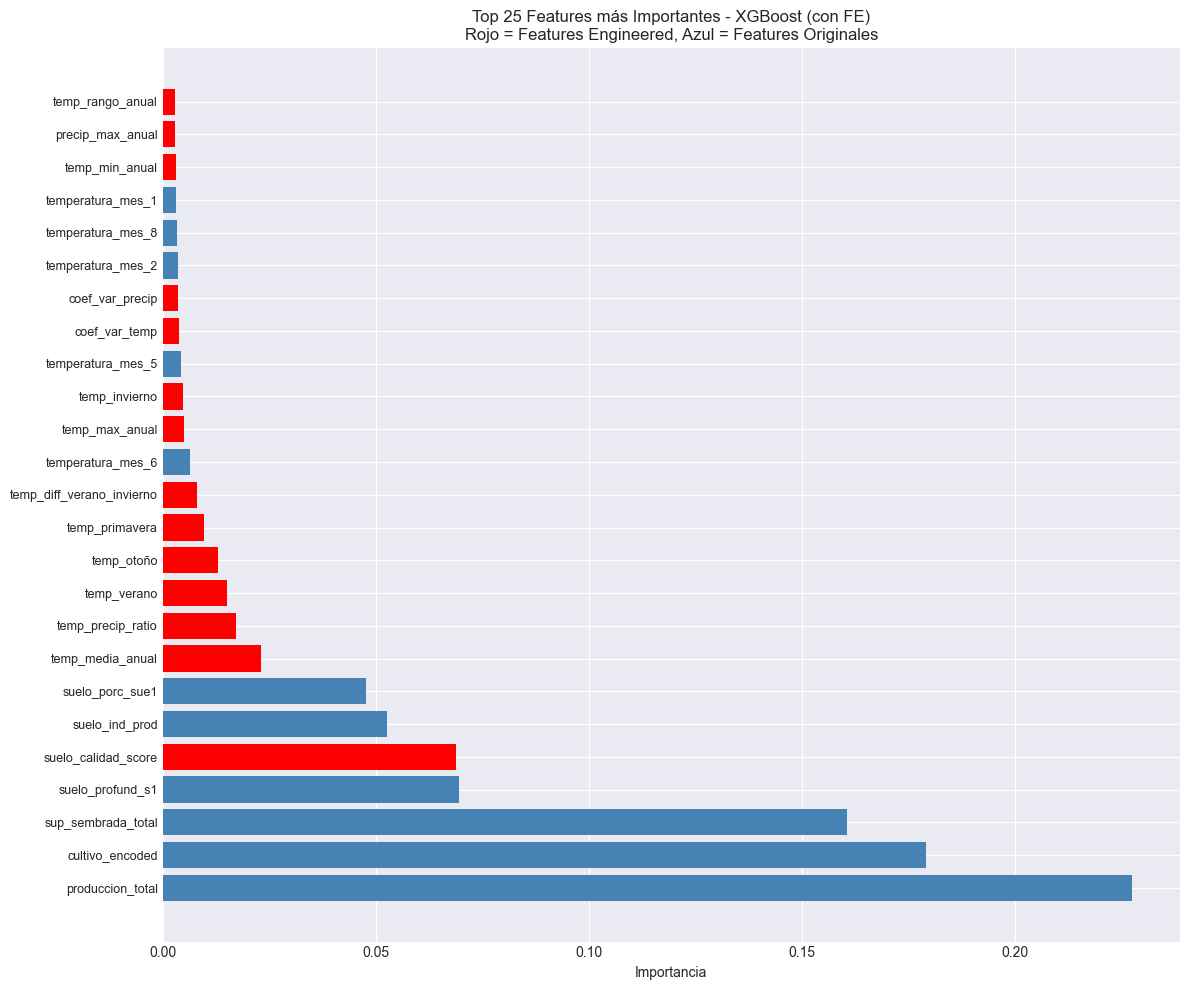

In [18]:
plt.figure(figsize=(12, 10))
top_n = 25
top_features = feature_importance_eng.head(top_n)

colors = ['red' if feat in new_features else 'steelblue' for feat in top_features['feature']]

plt.barh(range(top_n), top_features['importance'].values, color=colors)
plt.yticks(range(top_n), top_features['feature'].values, fontsize=9)
plt.xlabel('Importancia')
plt.title(f'Top {top_n} Features más Importantes - XGBoost (con FE)\nRojo = Features Engineered, Azul = Features Originales')
plt.tight_layout()
plt.savefig('../figures/xgb_feature_importance_with_fe.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Guardar Modelos y Datos

In [19]:
with open('../models/lr_x_eng.pkl', 'wb') as f:
    pickle.dump(lr_x_eng, f)

with open('../models/lr_z_eng.pkl', 'wb') as f:
    pickle.dump(lr_z_eng, f)

with open('../models/xgb_x_eng.pkl', 'wb') as f:
    pickle.dump(xgb_x_eng, f)

with open('../models/xgb_z_eng.pkl', 'wb') as f:
    pickle.dump(xgb_z_eng, f)

print("Modelos con feature engineering guardados.")

Modelos con feature engineering guardados.


In [20]:
# Guardar conjuntos TRAIN, VAL, TEST con feature engineering
np.save('../data/processed/X_train_eng.npy', X_train_eng)
np.save('../data/processed/X_val_eng.npy', X_val_eng)
np.save('../data/processed/X_test_eng.npy', X_test_eng)
np.save('../data/processed/y_train_eng.npy', y_train_eng)
np.save('../data/processed/y_val_eng.npy', y_val_eng)
np.save('../data/processed/y_test_eng.npy', y_test_eng)

np.save('../data/processed/X_train_eng_scaled.npy', X_train_eng_scaled)
np.save('../data/processed/X_val_eng_scaled.npy', X_val_eng_scaled)
np.save('../data/processed/X_test_eng_scaled.npy', X_test_eng_scaled)

np.save('../data/processed/X_train_eng_pca.npy', X_train_eng_pca)
np.save('../data/processed/X_val_eng_pca.npy', X_val_eng_pca)
np.save('../data/processed/X_test_eng_pca.npy', X_test_eng_pca)

with open('../data/processed/feature_cols_eng.pkl', 'wb') as f:
    pickle.dump(feature_cols_eng, f)

with open('../data/processed/scaler_eng.pkl', 'wb') as f:
    pickle.dump(scaler_eng, f)

with open('../data/processed/pca_eng.pkl', 'wb') as f:
    pickle.dump(pca_eng, f)

print("Datos y objetos guardados:")
print("  - 6 archivos base (X_train_eng, X_val_eng, X_test_eng, y_train_eng, y_val_eng, y_test_eng)")
print("  - 3 archivos scaled (X_train_eng_scaled, X_val_eng_scaled, X_test_eng_scaled)")
print("  - 3 archivos PCA (X_train_eng_pca, X_val_eng_pca, X_test_eng_pca)")
print("  - 3 objetos (feature_cols_eng.pkl, scaler_eng.pkl, pca_eng.pkl)")

Datos y objetos guardados:
  - 6 archivos base (X_train_eng, X_val_eng, X_test_eng, y_train_eng, y_val_eng, y_test_eng)
  - 3 archivos scaled (X_train_eng_scaled, X_val_eng_scaled, X_test_eng_scaled)
  - 3 archivos PCA (X_train_eng_pca, X_val_eng_pca, X_test_eng_pca)
  - 3 objetos (feature_cols_eng.pkl, scaler_eng.pkl, pca_eng.pkl)


In [21]:
results_summary_fe = {
    'lr_x_eng': results_lr_x_eng,
    'lr_z_eng': results_lr_z_eng,
    'xgb_x_eng': results_xgb_x_eng,
    'xgb_z_eng': results_xgb_z_eng
}

with open('../results/feature_engineering_results.pkl', 'wb') as f:
    pickle.dump(results_summary_fe, f)

print("Resultados guardados.")

Resultados guardados.
